In [31]:
import pyspedas
import pytplot
from matplotlib import pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
import matplotlib.cm as cm

import scipy
from scipy import interpolate,optimize
from scipy.optimize import curve_fit
from skimage.transform import probabilistic_hough_line

import helper
from helper import UTC_to_UNX
from helper import find_closest_index_dt

import dateutil
from dateutil.parser import parse

In [3]:
start = '2023-01-03'
end = '2023-01-04'
time_clip = True
no_update = False
varnames_hfr = 'psp_fld_l3_rfs_hfr_auto_averages_ch0_V1V2'
varnames_lfr = 'psp_fld_l3_rfs_lfr_auto_averages_ch0_V1V2'
rfs_hfr_vars = pyspedas.psp.fields(trange=[start, end], datatype='rfs_hfr', level='l3', no_update=no_update, varnames=varnames_hfr)
rfs_lfr_vars = pyspedas.psp.fields(trange=[start, end], datatype='rfs_lfr', level='l3', no_update=no_update, varnames=varnames_lfr)
rfs_ch0_hfr = pyspedas.get('psp_fld_l3_rfs_hfr_auto_averages_ch0_V1V2')
rfs_ch0_lfr = pyspedas.get('psp_fld_l3_rfs_lfr_auto_averages_ch0_V1V2')
data_hfr = rfs_ch0_hfr.y
freq_hfr = rfs_ch0_hfr.v
times_hfr = rfs_ch0_hfr.times

data_lfr = rfs_ch0_lfr.y
freq_lfr = rfs_ch0_lfr.v
times_lfr = rfs_ch0_lfr.times

27-Sep-25 01:06:04: Downloading remote index: https://spdf.gsfc.nasa.gov/pub/data/psp/fields/l3/rfs_hfr/2023/
27-Sep-25 01:06:05: File is current: psp_data/fields/l3/rfs_hfr/2023/psp_fld_l3_rfs_hfr_20230103_v03.cdf
27-Sep-25 01:06:05: Downloading remote index: https://spdf.gsfc.nasa.gov/pub/data/psp/fields/l3/rfs_hfr/2023/
27-Sep-25 01:06:05: File is current: psp_data/fields/l3/rfs_hfr/2023/psp_fld_l3_rfs_hfr_20230103_v03.cdf
27-Sep-25 01:06:05: Downloading remote index: https://spdf.gsfc.nasa.gov/pub/data/psp/fields/l3/rfs_lfr/2023/
27-Sep-25 01:06:06: File is current: psp_data/fields/l3/rfs_lfr/2023/psp_fld_l3_rfs_lfr_20230103_v03.cdf
27-Sep-25 01:06:06: Downloading remote index: https://spdf.gsfc.nasa.gov/pub/data/psp/fields/l3/rfs_lfr/2023/
27-Sep-25 01:06:06: File is current: psp_data/fields/l3/rfs_lfr/2023/psp_fld_l3_rfs_lfr_20230103_v03.cdf


In [19]:
dyspec = data_hfr
t_fits = times_hfr
full_f_fits = np.concatenate((freq_lfr[0], freq_hfr[0]))
full_data = np.concatenate((data_lfr, data_hfr), axis = 1)

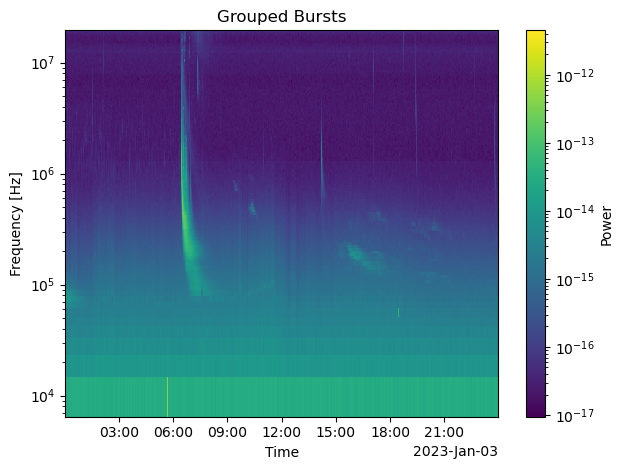

In [21]:
fig, ax = plt.subplots()
p = ax.pcolormesh(times_hfr, full_f_fits, full_data.T, norm=LogNorm())
plt.colorbar(p, label='Power')

plt.xlabel("Time")
plt.ylabel("Frequency [Hz]")
plt.yscale('log')
plt.title("Grouped Bursts")
# plt.grid(True)
plt.tight_layout()
plt.show()

In [23]:
def binarization(data_fits_new,N_order=2,peak_r=0.9):
    # with high order local-max method 
    # original default arguments : N_order = 5
    # peak_r = 0.95
    bmap = np.ones_like(data_fits_new)
    N_pad = N_order
    local_max_arr = np.pad(data_fits_new,((N_pad,N_pad),(0,0)))
    for idx in range(N_pad-1):
        bmap=bmap* ((peak_r*local_max_arr[N_pad+idx+1:-N_pad+idx+1,:]<
                            local_max_arr[N_pad+idx:-N_pad+idx,:]) & 
                    (peak_r*local_max_arr[N_pad-idx-1:-N_pad-idx-1,:]<
                            local_max_arr[N_pad-idx:-N_pad-idx,:]) )
    return bmap

bmap = binarization(full_data)
bmap

array([[1., 1., 1., ..., 1., 1., 1.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 1., 1., ..., 1., 1., 1.],
       ...,
       [0., 1., 0., ..., 1., 0., 1.],
       [1., 0., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 0.]], dtype=float32)

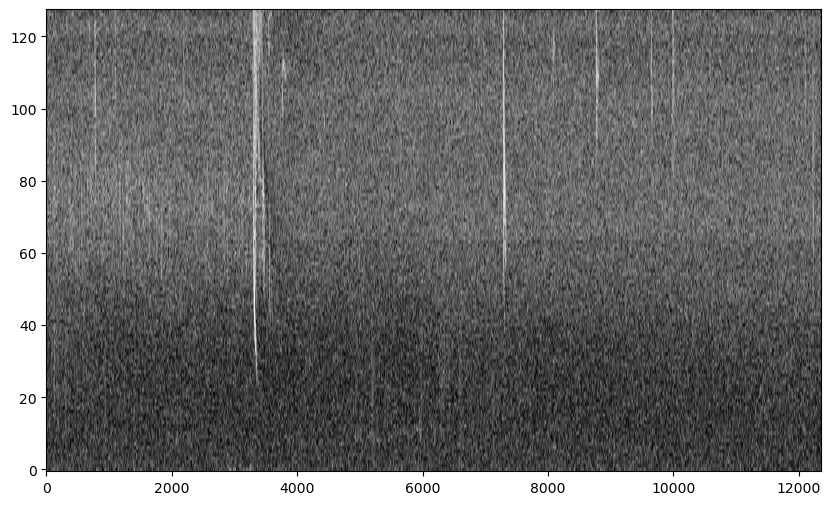

In [549]:
plt.figure(figsize=(10, 6))
plt.imshow(1-bmap.T, aspect='auto', origin='lower',cmap='gray')
plt.show()

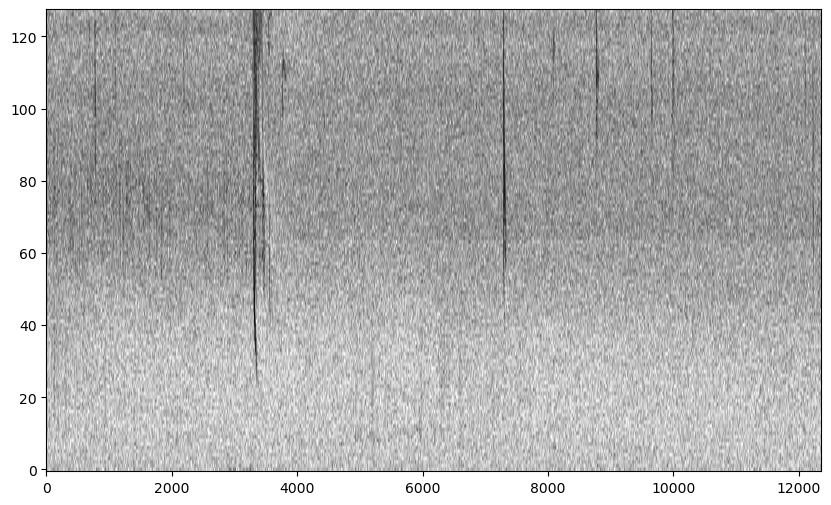

In [551]:
plt.figure(figsize=(10, 6))
plt.imshow(bmap.T, aspect='auto', origin='lower',cmap='gray')
plt.show()

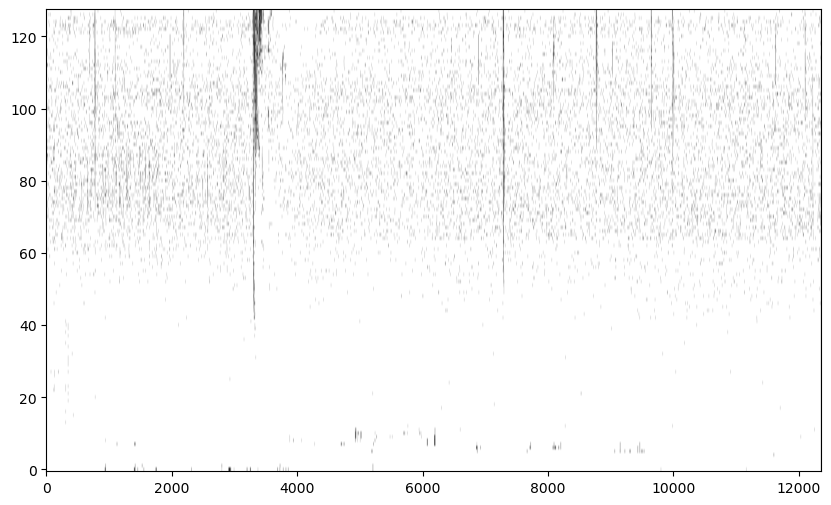

In [535]:
plt.figure(figsize=(10, 6))
plt.imshow(binarization(full_data,N_order=3,peak_r=0.65).T, aspect='auto', origin='lower',cmap='gray')
plt.show()

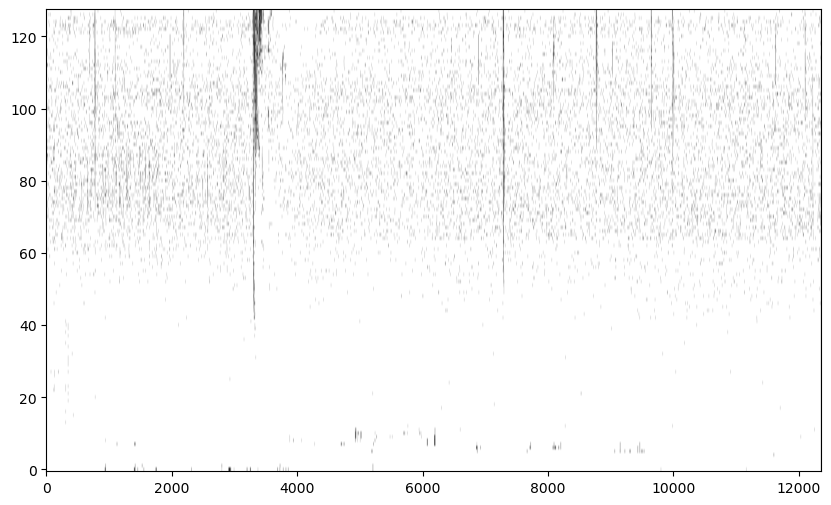

In [537]:
plt.figure(figsize=(10, 6))
plt.imshow(binarization(full_data,N_order=3,peak_r=0.65).T, aspect='auto', origin='lower',cmap='gray')
plt.show()

In [25]:
bmap_bin = binarization(bmap)
bmap_bin

array([[1., 1., 1., ..., 1., 1., 1.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 1., 1., ..., 1., 1., 1.],
       ...,
       [0., 1., 0., ..., 1., 0., 1.],
       [1., 0., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 0.]], dtype=float32)

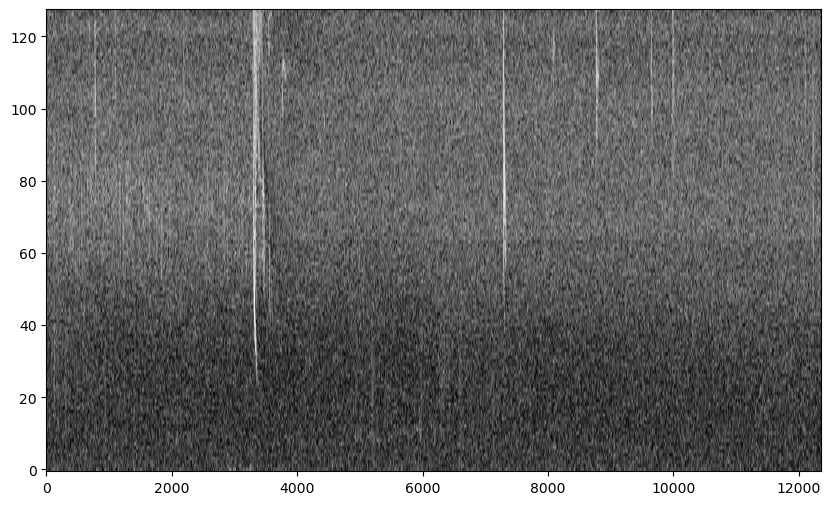

In [27]:
plt.figure(figsize=(10, 6))
plt.imshow(1-bmap_bin.T, aspect='auto', origin='lower',cmap='gray')
plt.show()

In [29]:
def hough_detect(bmap,dyspec,threshold=50,line_gap=10,line_length=25,
            theta=np.linspace(np.pi/2-np.pi/8,np.pi/2-1/180*np.pi,300)):
    threshold = 10
    line_gap = 10 # originally 50
    line_length = 30 # originally 10
    lines = probabilistic_hough_line(bmap, threshold=threshold,line_gap=line_gap,line_length=line_length,
                                 theta=theta)
    return lines

lines = hough_detect(1-bmap, full_data)
lines

[((42, 2973), (125, 2939)),
 ((29, 7384), (127, 7377)),
 ((60, 937), (126, 931)),
 ((0, 2990), (90, 2954)),
 ((0, 8904), (125, 8873)),
 ((38, 3412), (127, 3390)),
 ((40, 8502), (127, 8481)),
 ((79, 8491), (124, 8481)),
 ((26, 1226), (125, 1204)),
 ((1, 735), (126, 720)),
 ((2, 11540), (120, 11526)),
 ((4, 7320), (124, 7285)),
 ((8, 9994), (127, 9946)),
 ((17, 11290), (126, 11254)),
 ((13, 7425), (127, 7393)),
 ((13, 3226), (127, 3215)),
 ((46, 2972), (127, 2940)),
 ((0, 12326), (127, 12284)),
 ((4, 6928), (127, 6912)),
 ((0, 11082), (126, 11048)),
 ((1, 6771), (122, 6732)),
 ((3, 9997), (85, 9964)),
 ((0, 582), (127, 534)),
 ((10, 8921), (59, 8902)),
 ((3, 6139), (127, 6133)),
 ((0, 9285), (125, 9279)),
 ((43, 6829), (124, 6806)),
 ((39, 8790), (127, 8785)),
 ((46, 11656), (126, 11653)),
 ((14, 9912), (123, 9876)),
 ((79, 6134), (125, 6132)),
 ((37, 8896), (127, 8873)),
 ((14, 11176), (125, 11132)),
 ((0, 9356), (125, 9330)),
 ((5, 11323), (123, 11304)),
 ((0, 879), (38, 866)),
 ((38, 

In [11]:
norm = np.linalg.norm
def point_to_line_distance(p1,p2,p3):
    d = np.abs(norm(np.cross(p2-p1, p1-p3)))/norm(p2-p1)
    return d

def point_to_point_distance(p1,p2):
    return norm(p1-p2)

In [13]:
def line_grouping(lines,min_dist=3, threshmode=2): # pix
    """
    Parameters
    ----------
    lines : list
        list of lines detected by hough transform.
    min_dist : float, optional  # pix
        minimum distance between two lines to be grouped together.
    threshmode : int, optional
        DESCRIPTION. 1: only distance of point to line
                        2: distance of point to line and angle between lines
    """
    # group the detected lines into group in regard of events
    lines = sorted(lines, key=lambda i: (i[0][1]+i[1][1])/2)
    line_sets = [[lines[0]]]
    for idx,line in enumerate(lines[0:-1]):
        (A,B),(C,D) = np.array([lines[idx], lines[idx+1] ])

        # use the longer line as the reference
        l_AB = norm(A-B)
        l_CD = norm(C-D)
        if l_AB<l_CD:
            A,B,C,D = C,D,A,B
        
        # point to line distance
        Line_dist_thresh = np.min([point_to_line_distance(A,B,C),point_to_line_distance(A,B,D)])< min_dist
        Line_dist_thresh2 = np.min([point_to_line_distance(A,B,C),point_to_line_distance(A,B,D)])< min_dist*1.5

        # two lines segment not too far away
        Point_dist_thresh = np.min([point_to_point_distance(A,C),point_to_point_distance(A,D),
                                    point_to_point_distance(B,C),point_to_point_distance(B,D)])< np.max(
                                        [point_to_point_distance(A,B),point_to_point_distance(C,D)])
       
        if threshmode==1:
            final_thresh = Line_dist_thresh
        elif threshmode==2:
            final_thresh = Line_dist_thresh & Point_dist_thresh
        elif threshmode==3:
            if B[0]>C[0] and B[1]>C[1]:
                final_thresh = Line_dist_thresh2 & Point_dist_thresh

        if final_thresh:
            # the line join
            line_sets[len(line_sets)-1].append(lines[idx+1])
        else:
            # new set
            line_sets.append([lines[idx+1]])
    
    return line_sets

line_sets = line_grouping(lines)
line_sets

[[((0, 1), (73, 0)),
  ((5, 2), (103, 0)),
  ((0, 3), (96, 1)),
  ((93, 3), (126, 3)),
  ((0, 4), (61, 3)),
  ((0, 8), (126, 0)),
  ((67, 8), (97, 0))],
 [((0, 5), (51, 4))],
 [((68, 8), (124, 1)), ((0, 11), (111, 0)), ((0, 12), (112, 1))],
 [((50, 13), (89, 0)), ((0, 9), (55, 5)), ((82, 13), (113, 1))],
 [((31, 9), (62, 6))],
 [((86, 16), (127, 0))],
 [((84, 9), (127, 7)),
  ((59, 15), (116, 4)),
  ((0, 19), (127, 2)),
  ((0, 16), (97, 5)),
  ((0, 14), (64, 7)),
  ((1, 12), (57, 9)),
  ((0, 13), (48, 8))],
 [((57, 15), (91, 8))],
 [((65, 24), (125, 0))],
 [((33, 20), (127, 4)), ((91, 18), (127, 6)), ((81, 19), (124, 5))],
 [((6, 14), (36, 11))],
 [((73, 16), (127, 10))],
 [((0, 20), (66, 6)), ((0, 22), (107, 5))],
 [((35, 20), (127, 8))],
 [((6, 28), (86, 0)), ((5, 29), (108, 0))],
 [((1, 18), (39, 11)), ((0, 17), (39, 13)), ((10, 22), (61, 8))],
 [((64, 28), (127, 3)),
  ((74, 22), (124, 12)),
  ((3, 20), (76, 14)),
  ((0, 24), (127, 11)),
  ((79, 23), (121, 12))],
 [((38, 35), (127,

<Figure size 1000x600 with 0 Axes>

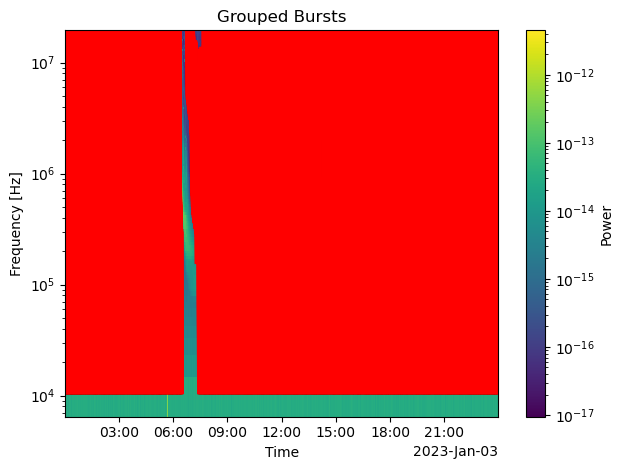

In [14]:
plt.figure(figsize=(10, 6))

fig, ax = plt.subplots()
p = ax.pcolormesh(times_hfr, full_f_fits, full_data.T, norm=LogNorm())
plt.colorbar(p, label='Power')

for line_group in line_sets:
    for (x0, y0), (x1, y1) in line_group:
        t0, t1 = t_fits[y0], t_fits[y1]
        f0, f1 = full_f_fits[x0], full_f_fits[x1]
        # print(t0, t1, f0, f1)
        ax.plot([t0, t1], [f0, f1], color='red')

plt.xlabel("Time")
plt.ylabel("Frequency [Hz]")
plt.yscale('log')
plt.title("Grouped Bursts")
# plt.grid(True)
plt.tight_layout()
plt.show()

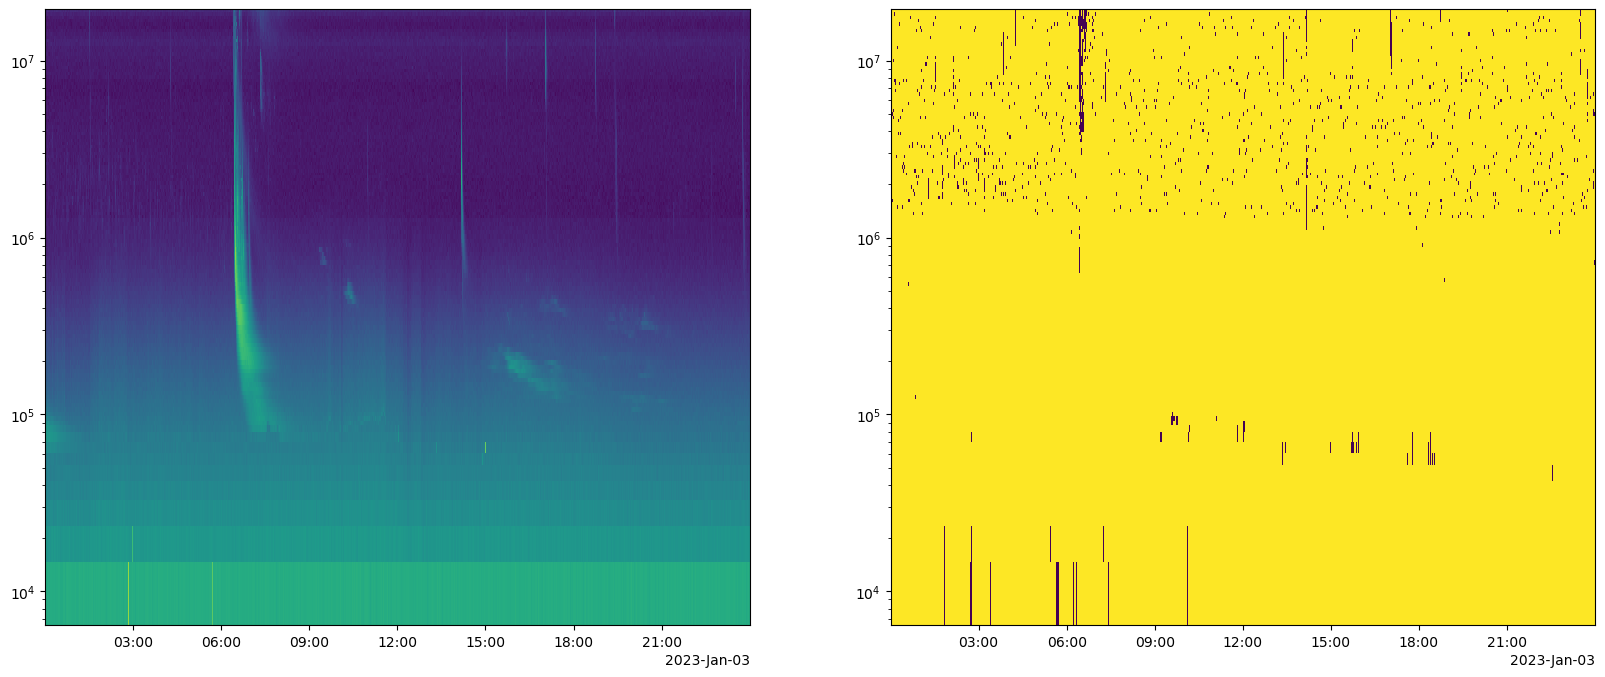

In [65]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

ax1.pcolormesh(times_hfr, full_f_fits, full_data.T, norm=LogNorm())
ax1.set_yscale('log')

# ax2.imshow(binarization(full_data,N_order=3,peak_r=0.6).T, aspect='auto', origin='lower',cmap='gray')
ax2.pcolormesh(times_hfr, full_f_fits, binarization(full_data,N_order=5,peak_r=0.6).T)
ax2.set_yscale('log')

# for line_group in line_sets:
#     for (x0, y0), (x1, y1) in line_group:
#         t0, t1 = t_fits[y0], t_fits[y1]
#         f0, f1 = full_f_fits[x0], full_f_fits[x1]
        # print(t0, t1, f0, f1)
        # ax1.plot([t0, t1], [f0, f1], color='red')
        # ax2.plot([t0, t1], [f0, f1], color='red')
        
plt.show()

In [233]:
full_data.shape

(12359, 128)

In [235]:
bmap.shape

(12359, 128)

In [13]:
y.shape

(128,)

In [17]:
full_data.shape

(12359, 128)

In [43]:
help(parse)

Help on function parse in module dateutil.parser._parser:

parse(timestr, parserinfo=None, **kwargs)
    Parse a string in one of the supported formats, using the
    ``parserinfo`` parameters.

    :param timestr:
        A string containing a date/time stamp.

    :param parserinfo:
        A :class:`parserinfo` object containing parameters for the parser.
        If ``None``, the default arguments to the :class:`parserinfo`
        constructor are used.

    The ``**kwargs`` parameter takes the following keyword arguments:

    :param default:
        The default datetime object, if this is a datetime object and not
        ``None``, elements specified in ``timestr`` replace elements in the
        default object.

    :param ignoretz:
        If set ``True``, time zones in parsed strings are ignored and a naive
        :class:`datetime` object is returned.

    :param tzinfos:
        Additional time zone names / aliases which may be present in the
        string. This argument map

In [45]:
times_hfr

array(['2023-01-03T00:00:04.368307840', '2023-01-03T00:00:11.358787072',
       '2023-01-03T00:00:18.349266176', ...,
       '2023-01-03T23:59:39.176348032', '2023-01-03T23:59:46.166827264',
       '2023-01-03T23:59:53.157306368'], dtype='datetime64[ns]')

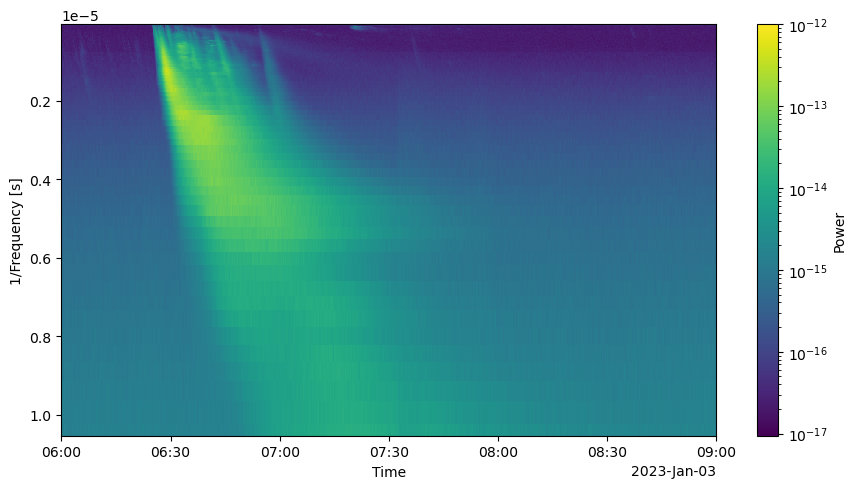

In [47]:
y = 1.0 / full_f_fits
fig, ax = plt.subplots(figsize=(9,5))    

pm = ax.pcolormesh(times_hfr, y[10:][::-1], full_data[:,10:].T, shading='auto', norm=LogNorm())
fig.colorbar(pm, ax=ax, label='Power')

ax.set_xlabel("Time")
ax.set_ylabel("1/Frequency [s]")
ax.set_ylim(y[10:].max(), y[10:].min()) # reflect over the x-axis
ax.set_xlim([parse('2023 01 03 6:00'), parse('2023 01 03 9:00')])

plt.tight_layout()
plt.show()

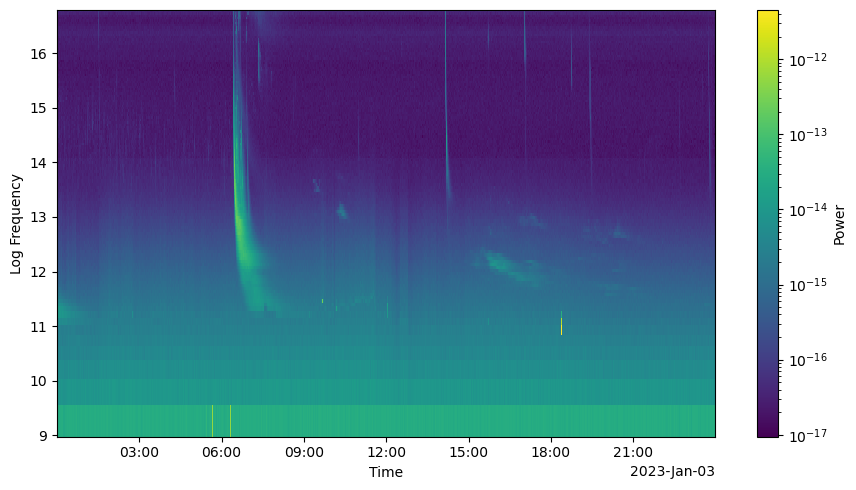

In [11]:
log_y = np.log(full_f_fits)
fig, ax = plt.subplots(figsize=(9,5))

pm = ax.pcolormesh(times_hfr, log_y, full_data.T, shading='auto', norm=LogNorm())
fig.colorbar(pm, ax=ax, label='Power')

ax.set_xlabel("Time")
ax.set_ylabel("Log Frequency")

# ax.set_ylim(y.max(), y.min()) # reflect over the x-axis

plt.tight_layout()
plt.show()

In [97]:
times_hfr[3090:]

array(['2023-01-03T06:00:05.061529472', '2023-01-03T06:00:12.052252928',
       '2023-01-03T06:00:19.042732032', ...,
       '2023-01-03T23:59:39.176348032', '2023-01-03T23:59:46.166827264',
       '2023-01-03T23:59:53.157306368'], dtype='datetime64[ns]')

In [103]:
new_times = UTC_to_UNX(times_hfr)
new_times

array([1.67270400e+09, 1.67270401e+09, 1.67270402e+09, ...,
       1.67279038e+09, 1.67279039e+09, 1.67279039e+09])

In [113]:
idx = find_closest_index_dt(parse('2023 01 03 6:00'), new_times)

In [109]:
full_data.shape

(12359, 128)

In [115]:
full_data[idx]

array([2.6896035e-14, 9.6555895e-15, 5.7041592e-15, 4.2017209e-15,
       2.6964826e-15, 2.6733012e-15, 2.3409208e-15, 2.2716784e-15,
       1.7425781e-15, 1.4766779e-15, 1.4208753e-15, 1.2344611e-15,
       1.2446295e-15, 1.1682021e-15, 1.0852346e-15, 9.7807085e-16,
       8.1097523e-16, 8.3044667e-16, 7.8449920e-16, 7.2913814e-16,
       6.1516911e-16, 6.2275175e-16, 5.1216721e-16, 4.7145827e-16,
       4.5024936e-16, 3.8419731e-16, 3.2991806e-16, 3.2635070e-16,
       2.7781460e-16, 2.5137828e-16, 2.4224621e-16, 2.1183616e-16,
       1.9568465e-16, 1.8017353e-16, 1.5732958e-16, 1.3678404e-16,
       1.3353060e-16, 1.2340922e-16, 1.0299275e-16, 9.8089029e-17,
       8.8440536e-17, 9.3911264e-17, 8.1022784e-17, 7.0988495e-17,
       6.5312964e-17, 6.5238147e-17, 5.5278694e-17, 5.9888287e-17,
       5.0551581e-17, 3.7976527e-17, 3.6119040e-17, 4.2464921e-17,
       4.5232929e-17, 4.1779060e-17, 3.8403600e-17, 6.5206390e-17,
       3.9948489e-17, 4.2919689e-17, 3.7799305e-17, 2.9681815e

In [121]:
idx_bin = bmap[idx]
idx_bin

array([0., 0., 1., 1., 0., 1., 1., 1., 1., 1., 0., 1., 0., 1., 0., 1., 0.,
       1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1., 0., 0., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0.,
       0., 0., 1., 1., 1., 1., 0., 1., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
       0., 0., 1., 0., 0., 0., 1., 1., 1., 1., 0., 0., 1., 1., 1., 1., 1.,
       1., 1., 0., 1., 1., 1., 0., 1., 1., 0., 0., 1., 1., 0., 0., 0., 0.,
       0., 1., 1., 0., 1., 0., 1., 1., 0., 0., 0., 1., 1., 1., 1., 1., 1.,
       0., 0., 1., 0., 1., 0., 1., 1., 1.], dtype=float32)

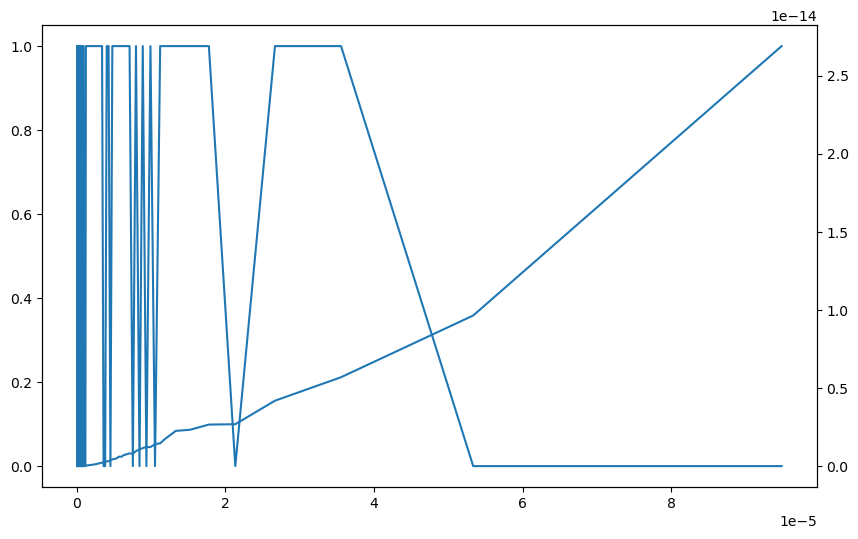

In [135]:
fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.plot(y, bmap[idx])
ax2 = ax1.twinx()
ax2.plot(y, full_data[idx])

plt.show()